# Predicting from a continuous connectome, with every fit inside the folds

A connectome predicts a trait only if everything learned from the data is learned without the
subjects it is tested on. For a continuous connectome that includes the functional PCA basis and
the cohort mean it is centred on, as well as the scaling, the model and its penalty; and with
twins and siblings in the cohort, a family has to stay on one side of every split. This notebook
does all of it for 300 HCP young adults and two traits, sex and fluid intelligence (the number
of PMAT24 items answered correctly), from the continuous connectome's component scores and,
beside them, from the Schaefer-200 region matrices of the same files.

`scripts/prediction_data.py` draws the sample family by family, deals the families to five
folds, and fits a rank-15 basis to each fold's training subjects, scoring all 300 on it (about
an hour a fold on the cluster). Everything else happens here, in about 17 minutes on 8 cores
and 6 GB of memory. The families are restricted HCP data: they are read from outside the repository, and only counts
appear below.

In [1]:
import csv
import warnings
from pathlib import Path
from tempfile import mkdtemp

import matplotlib.pyplot as plt
import numpy as np
from joblib import Memory
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, GroupKFold, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# The lab's copies on Longleaf; point these at your own files.
ROOT = Path("/work/users/x/y/xya/hcp-ya")
DATA = ROOT / "prediction"  # what scripts/prediction_data.py wrote
TRAITS = ROOT / "open_access_traits.csv"  # subject, sex, age_bin, fluid_intelligence_pmat24
FAMILIES = ROOT / "restricted" / "families.csv"  # restricted HCP data: read here, never shown
FOLDS, RANK = 5, 15
# A training split's scaling and PCA are the same for every grid point; fit them once. (joblib
# remarks that hashing the region matrices takes a moment; it does, harmlessly.)
CACHE = Memory(mkdtemp(prefix="sbci-prediction-"), verbose=0)
warnings.filterwarnings("ignore", message="Persisting input arguments")

BLUE, ORANGE, INK, MUTED, RULE = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#d9d8d3"
plt.rcParams.update({
    "font.size": 10, "text.color": INK, "axes.labelcolor": MUTED, "axes.edgecolor": RULE,
    "axes.spines.top": False, "axes.spines.right": False, "xtick.color": MUTED,
    "ytick.color": MUTED, "figure.facecolor": "white", "figure.dpi": 110,
})

## 1. The sample and its folds

Three hundred subjects in 134 families: 27 alone, 56 pairs, 43 of three and 8 of four. Dealt
whole to five folds of 60, no family has members in two folds. Men are 48% of the sample, and
fluid intelligence averages 16.9 of 24 (sd 4.9). Head size will matter: the brain-mask volume
averages 1.74 L in men and 1.50 L in women.

In [2]:
with open(DATA / "sample.csv", newline="") as handle:
    rows = list(csv.DictReader(handle))
subjects = np.array([row["subject"] for row in rows])
fold = np.array([int(row["fold"]) for row in rows])
with open(TRAITS, newline="") as handle:
    traits = {row["subject"]: row for row in csv.DictReader(handle)}
with open(FAMILIES, newline="") as handle:
    family_of = {row["subject"]: row["group"] for row in csv.DictReader(handle)}
family = np.unique([family_of[s] for s in subjects], return_inverse=True)[1]  # codes 0, 1, ...
del family_of

men = np.array([traits[s]["sex"] == "M" for s in subjects], dtype=int)
pmat = np.array([float(traits[s]["fluid_intelligence_pmat24"]) for s in subjects])
BAND = {"22-25": 23.5, "26-30": 28.0, "31-35": 33.0, "36+": 37.0}
age = np.array([BAND[traits[s]["age_bin"]] for s in subjects])
covariates = np.load(DATA / "covariates.npz")
assert (covariates["subjects"] == subjects).all()
head = np.column_stack([covariates["brain_volume"], covariates["streamlines"]])

sizes = np.bincount(np.bincount(family))
print(f"{subjects.size} subjects in {family.max() + 1} families, of "
      + ", ".join(f"{size} ({count})" for size, count in enumerate(sizes) if size and count)
      + " members (how many families)")
assert all(len(set(fold[family == f])) == 1 for f in range(family.max() + 1))
print(f"{FOLDS} folds of {np.bincount(fold).tolist()} subjects; no family is split between two")
print(f"{men.mean():.0%} men; PMAT24 {pmat.mean():.1f} correct of 24 on average (sd {pmat.std():.1f})")
print(f"brain-mask volume {head[men == 1, 0].mean():.2f} L in men on average, "
      f"{head[men == 0, 0].mean():.2f} L in women")

300 subjects in 134 families, of 1 (27), 2 (56), 3 (43), 4 (8) members (how many families)
5 folds of [60, 60, 60, 60, 60] subjects; no family is split between two
48% men; PMAT24 16.9 correct of 24 on average (sd 4.9)
brain-mask volume 1.74 L in men on average, 1.50 L in women


## 2. Features, each fitted on training subjects alone

For each fold the basis comes from its 240 training subjects alone, and captures 26.0% to 26.4%
of their norm in 15 components; the 60 held-out subjects are scored on it with `sbci.project`,
exactly as the training subjects are. The Schaefer-200 matrices, 19,900 region pairs a subject,
are reduced inside the model instead, by a PCA fitted in each training split. Their logarithm,
one fixed transform for everyone, comes first.

In [3]:
position = {subject: i for i, subject in enumerate(subjects)}
component_scores = []
for k in range(FOLDS):
    data = np.load(DATA / f"fold{k}.npz")
    assert set(data["test"]) == set(subjects[fold == k]) and set(data["train"]) == set(subjects[fold != k])
    scores = np.empty((subjects.size, RANK))
    scores[[position[s] for s in data["train"]]] = data["train_scores"]
    scores[[position[s] for s in data["test"]]] = data["test_scores"]
    component_scores.append(scores)  # fold k's basis: every subject scored on it
    print(f"fold {k}: basis from {data['train'].size} subjects, {data['explained'][-1]:.1%} of their norm "
          f"in {RANK} components")

atlas = np.load(DATA / "atlas.npz")
assert (atlas["subjects"] == subjects).all()
print(f"Schaefer-200: {atlas['schaefer200'].shape[1]:,} region pairs a subject, "
      f"{np.mean(atlas['schaefer200'] == 0):.1%} of them zero")
# Region densities span orders of magnitude, and a few are zero. The logarithm is the same
# fixed transform for every subject, so it may come before the folds; what is fitted to the
# data -- the scaling, the PCA, the model -- waits for them.
regions = np.log10(atlas["schaefer200"] + 1e-9)

fold 0: basis from 240 subjects, 26.3% of their norm in 15 components
fold 1: basis from 240 subjects, 26.4% of their norm in 15 components
fold 2: basis from 240 subjects, 26.1% of their norm in 15 components
fold 3: basis from 240 subjects, 26.2% of their norm in 15 components
fold 4: basis from 240 subjects, 26.0% of their norm in 15 components


Schaefer-200: 19,900 region pairs a subject, 9.5% of them zero


## 3. One procedure for every model

Every model is fitted the same way. In each of the five outer folds a grid search over a
four-fold split of the training subjects, by family, chooses how many components to use (1 to
15) and the penalty; the scaling is fitted on the training subjects; and the held-out fold is
predicted once. The out-of-fold predictions of all 300 subjects are scored together, with a 95%
interval from resampling whole families.

In [4]:
class First(BaseEstimator, TransformerMixin):
    """The first k of the leading n columns (component scores), and every column after them."""

    def __init__(self, k=RANK, n=RANK):
        self.k, self.n = k, n

    def fit(self, x, y=None):
        self.n_features_in_ = x.shape[1]  # what marks a scikit-learn step as fitted
        return self

    def transform(self, x):
        return np.hstack([x[:, : self.k], x[:, self.n :]])


COMPONENTS = [1, 2, 3, 5, 8, 10, 15]
PENALTY = {"sex": {"logisticregression__C": np.logspace(-3, 2, 6)},
           "pmat": {"ridge__alpha": np.logspace(-1, 5, 7)}}


def estimator(target):
    return LogisticRegression(max_iter=10_000) if target == "sex" else Ridge()


def model(features, target, extra):
    """A pipeline and its grid. Columns: the features first, then the ``extra`` covariates."""
    if features == "covariates":
        return make_pipeline(StandardScaler(), estimator(target)), dict(PENALTY[target])
    if features == "continuous":
        grid = {"first__k": COMPONENTS, **PENALTY[target]}
        return make_pipeline(First(), StandardScaler(), estimator(target)), grid
    reduce = make_pipeline(StandardScaler(), PCA(n_components=RANK, random_state=0), First(),
                           memory=CACHE)
    columns = ColumnTransformer([("regions", reduce, slice(0, regions.shape[1])),
                                 ("covariates", "passthrough", slice(regions.shape[1], None))])
    grid = {"columntransformer__regions__first__k": COMPONENTS, **PENALTY[target]}
    return make_pipeline(columns, StandardScaler(), estimator(target)), grid


def design(features, k, extra):
    if features == "covariates":
        return extra
    base = component_scores[k] if features == "continuous" else regions
    return np.hstack([base, extra])


def out_of_fold(features, target, extra, splits=None, families=True):
    """Every subject's prediction from a model fitted, tuned and scaled without its fold.

    The outer folds are the sample's, families kept whole; inside each training fold a
    four-fold split by family chooses the number of components and the penalty.
    """
    y = men if target == "sex" else pmat
    splits = splits or [(fold != k, fold == k) for k in range(FOLDS)]
    predicted, chosen = np.empty(y.size), []
    for k, (train, test) in enumerate(splits):
        pipeline, grid = model(features, target, extra)
        inner = GroupKFold(n_splits=4) if families else KFold(4, shuffle=True, random_state=k)
        search = GridSearchCV(pipeline, grid, cv=inner, scoring="roc_auc" if target == "sex" else "r2",
                              n_jobs=-1)
        x = design(features, k, extra)
        search.fit(x[train], y[train], **({"groups": family[train]} if families else {}))
        predicted[test] = (search.predict_proba(x[test])[:, 1] if target == "sex"
                           else search.predict(x[test]))
        chosen.append({key.split("__")[-1]: value for key, value in search.best_params_.items()})
    return predicted, chosen


def by_family(metric, y, predicted, draws=2000):
    """A 95% interval for the metric, resampling whole families."""
    rng = np.random.default_rng(0)
    members = [np.flatnonzero(family == f) for f in range(family.max() + 1)]
    values = []
    for _ in range(draws):
        picked = np.concatenate([members[f] for f in rng.integers(0, len(members), len(members))])
        values.append(metric(y[picked], predicted[picked]))
    return np.percentile(values, [2.5, 97.5])


def pearson(y, predicted):
    return float(np.corrcoef(y, predicted)[0, 1])


def components(chosen):
    """What the inner folds chose in each outer fold: components, and the penalty."""
    penalty = "C" if "C" in chosen[0] else "alpha"
    picked = [(f"{c['k']} at " if "k" in c else "") + f"{penalty} {c[penalty]:g}" for c in chosen]
    return "chosen: " + "; ".join(picked)

## 4. Sex, and how much of it is head size

Sex is mostly head size here. Brain-mask volume and streamline count alone reach an AUC of 0.906
(0.858 to 0.944). The continuous components alone reach 0.657 (0.588 to 0.722), and Schaefer-200
alone 0.857 (0.813 to 0.898). Added to head size, the components bring the AUC down, to 0.873:
with 240 training subjects, weak extra features cost the model more than they bring. The regions
bring it to 0.923 (0.888 to 0.954), inside head size's own interval.

In [5]:
none = np.empty((subjects.size, 0))
sex_models = {
    "head size and streamlines": ("covariates", head),
    "continuous": ("continuous", none),
    "continuous, with head size": ("continuous", head),
    "Schaefer-200": ("regions", none),
    "Schaefer-200, with head size": ("regions", head),
}
sex_results, sex_chosen = {}, {}
for name, (features, extra) in sex_models.items():
    predicted, chosen = out_of_fold(features, "sex", extra)
    auc = roc_auc_score(men, predicted)
    low, high = by_family(roc_auc_score, men, predicted)
    sex_results[name], sex_chosen[name] = (auc, low, high), chosen
    print(f"{name:29s} AUC {auc:.3f} (95% interval {low:.3f} to {high:.3f}), "
          f"accuracy {np.mean((predicted > 0.5) == men):.0%}; {components(chosen)}")

head size and streamlines     AUC 0.906 (95% interval 0.858 to 0.944), accuracy 82%; chosen: C 0.001; C 0.1; C 0.1; C 10; C 1


continuous                    AUC 0.657 (95% interval 0.588 to 0.722), accuracy 60%; chosen: 10 at C 1; 15 at C 0.1; 10 at C 0.1; 10 at C 0.01; 15 at C 100


continuous, with head size    AUC 0.873 (95% interval 0.815 to 0.921), accuracy 85%; chosen: 3 at C 100; 8 at C 0.1; 5 at C 0.01; 10 at C 1; 1 at C 0.001


Schaefer-200                  AUC 0.857 (95% interval 0.813 to 0.898), accuracy 76%; chosen: 15 at C 10; 15 at C 0.1; 15 at C 0.1; 15 at C 0.1; 15 at C 1


Schaefer-200, with head size  AUC 0.923 (95% interval 0.888 to 0.954), accuracy 85%; chosen: 15 at C 1; 10 at C 0.001; 10 at C 0.001; 15 at C 1; 15 at C 0.1


## 5. Fluid intelligence

Fluid intelligence is not predictable from either connectome in this sample. Sex, age band, head
size and streamline count together give r = 0.33 (0.21 to 0.43); the continuous components alone
give r = -0.04 and the regions -0.003, intervals that leave room for no more than a small effect,
and neither adds to the covariates (0.28 and 0.34).

In [6]:
demographic = np.column_stack([men, age, head])
pmat_models = {
    "sex, age band, head size, streamlines": ("covariates", demographic),
    "continuous": ("continuous", none),
    "continuous, with those": ("continuous", demographic),
    "Schaefer-200": ("regions", none),
    "Schaefer-200, with those": ("regions", demographic),
}
pmat_results, pmat_predicted, pmat_chosen = {}, {}, {}
for name, (features, extra) in pmat_models.items():
    predicted, chosen = out_of_fold(features, "pmat", extra)
    pmat_chosen[name] = chosen
    r = pearson(pmat, predicted)
    low, high = by_family(pearson, pmat, predicted)
    r2 = 1 - np.sum((pmat - predicted) ** 2) / np.sum((pmat - pmat.mean()) ** 2)
    pmat_results[name], pmat_predicted[name] = (r, low, high), predicted
    print(f"{name:37s} r {r:6.3f} (95% interval {low:6.3f} to {high:6.3f}), R2 {r2:6.3f}; {components(chosen)}")

sex, age band, head size, streamlines r  0.325 (95% interval  0.212 to  0.433), R2  0.105; chosen: alpha 10; alpha 10; alpha 10; alpha 10; alpha 10


continuous                            r -0.042 (95% interval -0.149 to  0.070), R2 -0.022; chosen: 8 at alpha 100; 8 at alpha 100000; 8 at alpha 1000; 5 at alpha 100; 15 at alpha 1000


continuous, with those                r  0.275 (95% interval  0.157 to  0.382), R2  0.071; chosen: 8 at alpha 100; 1 at alpha 100; 5 at alpha 10; 5 at alpha 10; 2 at alpha 10


Schaefer-200                          r -0.003 (95% interval -0.150 to  0.134), R2 -0.019; chosen: 3 at alpha 100; 5 at alpha 100; 15 at alpha 10000; 1 at alpha 100; 8 at alpha 100


Schaefer-200, with those              r  0.336 (95% interval  0.223 to  0.438), R2  0.112; chosen: 1 at alpha 10; 2 at alpha 10; 2 at alpha 10; 1 at alpha 10; 3 at alpha 10


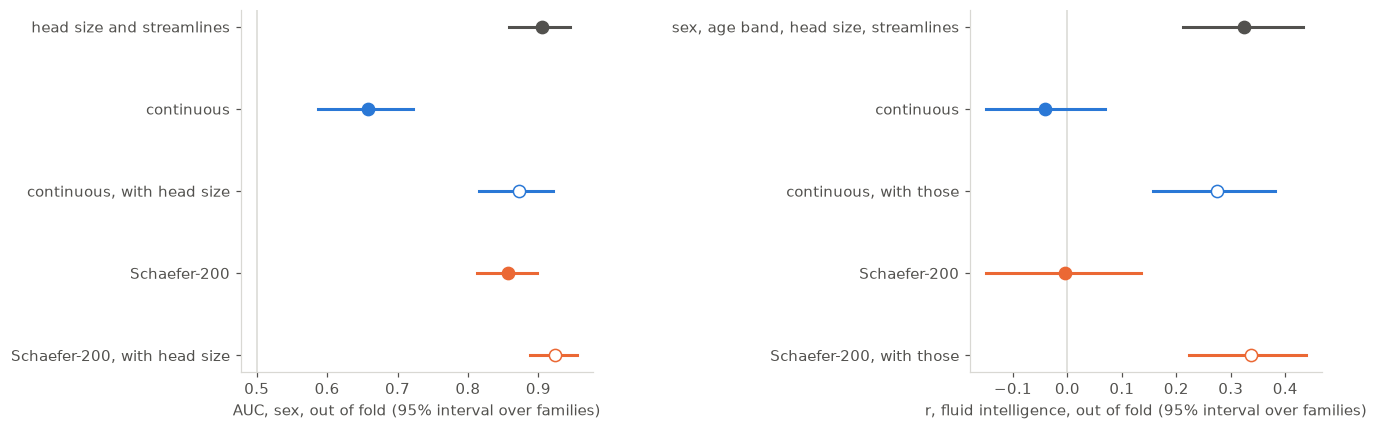

In [7]:
figure, (left, right) = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
figure.get_layout_engine().set(wspace=0.12)
for axis, results, label, chance in ((left, sex_results, "AUC, sex", 0.5),
                                     (right, pmat_results, "r, fluid intelligence", 0.0)):
    names = list(results)[::-1]
    for row, name in enumerate(names):
        value, low, high = results[name]
        colour = BLUE if name.startswith("continuous") else ORANGE if name.startswith("Schaefer") else MUTED
        axis.plot([low, high], [row, row], color=colour, linewidth=2)
        axis.plot(value, row, "o", color=colour, markersize=8,
                  markerfacecolor="white" if "with" in name else colour)
    axis.axvline(chance, color=RULE, linewidth=1, zorder=0)
    axis.set_yticks(range(len(names)), names)
    axis.set_xlabel(f"{label}, out of fold (95% interval over families)")
plt.show()

## 6. Why the components trail the regions

The two reductions differ in two ways. The region pairs are logged and standardised before their
PCA, and that PCA is free to weight the 19,900 pairs in any direction, where each functional
component is separable: a product of one surface map with itself, fitted to reconstruct the
continuous densities as they are. Taking the transform away -- a PCA of the raw region
densities, as the functional PCA takes the raw continuous ones -- brings the regions' AUC from
0.857 down to 0.775. The rest of the gap, to the components' 0.657, lies in the reductions
themselves: fifteen separable components, fitted to reconstruct the connectome rather than to
tell the sexes apart, carry less of what does.

In [8]:
raw = atlas["schaefer200"]  # the region densities as they are, neither logged nor standardised
predicted = np.empty(subjects.size)
for k in range(FOLDS):
    train, test = fold != k, fold == k
    reduce = make_pipeline(PCA(n_components=RANK, random_state=0), First(), memory=CACHE)
    pipeline = make_pipeline(ColumnTransformer([("regions", reduce, slice(0, raw.shape[1]))]),
                             StandardScaler(), LogisticRegression(max_iter=10_000))
    grid = {"columntransformer__regions__first__k": COMPONENTS, **PENALTY["sex"]}
    search = GridSearchCV(pipeline, grid, cv=GroupKFold(n_splits=4), scoring="roc_auc", n_jobs=-1)
    search.fit(raw[train], men[train], groups=family[train])
    predicted[test] = search.predict_proba(raw[test])[:, 1]
low, high = by_family(roc_auc_score, men, predicted)
print(f"Schaefer-200, raw densities, PCA: sex AUC {roc_auc_score(men, predicted):.3f} "
      f"(95% interval {low:.3f} to {high:.3f}); logged and standardised, "
      f"{sex_results['Schaefer-200'][0]:.3f}; the continuous components, {sex_results['continuous'][0]:.3f}")

Schaefer-200, raw densities, PCA: sex AUC 0.775 (95% interval 0.721 to 0.825); logged and standardised, 0.857; the continuous components, 0.657


## 7. What keeping families whole is for

Keeping families whole matters where a trait runs in families. Dealing the 300 subjects to folds
ten times at random, with the model the inner folds chose most often held fixed, fluid
intelligence's r is 0.088 (sd 0.023) with families split across folds and 0.017 (sd 0.059) with
them kept whole: twins and siblings on both sides of a split pass some of each other's score to
the model. For sex the two agree, 0.849 either way.

In [9]:
from collections import Counter


def typical(chosen):
    """The setting the inner folds chose most often for a model, held fixed here."""
    return {key: Counter(c[key] for c in chosen).most_common(1)[0][0] for key in chosen[0]}


def fixed(target, setting):
    model = (LogisticRegression(C=setting["C"], max_iter=10_000) if target == "sex"
             else Ridge(alpha=setting["alpha"]))
    return make_pipeline(StandardScaler(), PCA(n_components=RANK, random_state=0),
                         First(k=setting["k"]), StandardScaler(), model)


def score_folds(assignment, target, setting):
    """Out-of-fold predictions from one fixed model, for a given dealing of subjects to folds."""
    y = men if target == "sex" else pmat
    predicted = np.empty(y.size)
    for k in range(FOLDS):
        train, test = assignment != k, assignment == k
        model = fixed(target, setting).fit(regions[train], y[train])
        predicted[test] = (model.predict_proba(regions[test])[:, 1] if target == "sex"
                           else model.predict(regions[test]))
    return roc_auc_score(y, predicted) if target == "sex" else pearson(y, predicted)


REPEATS = 10
for target, chosen, label in (("sex", sex_chosen["Schaefer-200"], "sex, AUC"),
                              ("pmat", pmat_chosen["Schaefer-200"], "fluid intelligence, r")):
    setting = typical(chosen)
    whole, split, straddling = [], [], []
    for seed in range(REPEATS):
        rng = np.random.default_rng(seed)
        dealt = rng.permutation(family.max() + 1) % FOLDS  # each family to a fold at random
        shuffled = rng.permutation(subjects.size) % FOLDS  # each subject, families ignored
        straddling.append(sum(len(set(shuffled[family == f])) > 1 for f in range(family.max() + 1)))
        whole.append(score_folds(dealt[family], target, setting))
        split.append(score_folds(shuffled, target, setting))
    held = ", ".join(f"{key} {value:g}" for key, value in setting.items())
    print(f"Schaefer-200, {label} ({held}), {REPEATS} dealings each: "
          f"{np.mean(whole):.3f} (sd {np.std(whole):.3f}) with families kept whole, "
          f"{np.mean(split):.3f} (sd {np.std(split):.3f}) with them split, "
          f"{np.mean(straddling):.0f} of {family.max() + 1} families straddling folds")
CACHE.clear(warn=False)

Schaefer-200, sex, AUC (k 15, C 0.1), 10 dealings each: 0.849 (sd 0.011) with families kept whole, 0.849 (sd 0.012) with them split, 95 of 134 families straddling folds


Schaefer-200, fluid intelligence, r (k 3, alpha 100), 10 dealings each: 0.017 (sd 0.059) with families kept whole, 0.088 (sd 0.023) with them split, 95 of 134 families straddling folds


## What this says

- **Fit everything inside the training folds and keep families whole.** On fluid intelligence,
  splitting families raised r from about 0.02 to 0.09 -- a result that is all leak.
- **Check what the covariates alone do.** Sex here is head size first (AUC 0.91); neither
  connectome adds to it beyond its interval, and the components added to it take away.
- **At rank 15 the continuous components carry less about sex than a parcellation's PCA** (AUC
  0.66 against 0.86): the regions' transform accounts for part of it (raw region densities
  give 0.78), the reductions themselves the rest. Fluid intelligence is out of reach of both
  with 300 subjects.